# Admixture plotting

### Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import malariagen_data
from malariagen_data.anoph.admixture import novel_run_admixture_nmf

In [2]:
ag3 = malariagen_data.Ag3(
    "simplecache::gs://vo_agam_release_master_us_central1",
    simplecache=dict(cache_storage="../gcs_cache"),
    results_cache="results_cache",
)
ag3

NameError: name 'malariagen_data' is not defined

### Simulated data
Before running admixture analysis on real whole-genome sequencing data, we think that it is useful to validate the underlying Non-negative Matrix Factorization (NMF) algorithm on synthetic or dummy data where the true ancestry proportions are known.

For that, we simulated biallelic diplotype dosage data (values in `{0, 1, 2}`) for three well-separated ancestral populations, loosely mirroring the allele frequency spectra of *An. gambiae*, *An. coluzzii* and *An. arabiensis*, plus a cohort of 50:50 admixed samples.

In [3]:
rng = np.random.default_rng(42)

n_variants = 5_000   # biallelic SNPs
n_per_pop = 40        # pure-ancestry samples per population
n_admixed = 20        # hybrid gambiae x coluzzii samples

# True ancestral allele frequencies.
# Pop1 (gambiae-like): MAF 5-25%
# Pop2 (coluzzii-like): MAF 35-55%
# Pop3 (arabiensis-like): MAF 70-90%

p_true = np.column_stack(
    [
        rng.uniform(0.05, 0.25, n_variants),
        rng.uniform(0.35, 0.55, n_variants),
        rng.uniform(0.70, 0.90, n_variants),
    ]
)


def simulate_dosage(freq, n, rng=rng):
    return rng.binomial(2, freq, size=(n, len(freq))).astype(np.float32)


X_gambiae = simulate_dosage(p_true[:, 0], n_per_pop)
X_coluzzii = simulate_dosage(p_true[:, 1], n_per_pop)
X_arabiensis = simulate_dosage(p_true[:, 2], n_per_pop)

# Admixed samples: 50% gambiae x 50% coluzzii ancestry.
p_blend = 0.5 * p_true[:, 0] + 0.5 * p_true[:, 1]
X_admixed = simulate_dosage(p_blend, n_admixed)

X_sim = np.vstack([X_gambiae, X_coluzzii, X_arabiensis, X_admixed])
n_samples_sim = X_sim.shape[0]

population_sim = (
    ["gambiae"] * n_per_pop
    + ["coluzzii"] * n_per_pop
    + ["arabiensis"] * n_per_pop
    + ["admixed"] * n_admixed
)
sample_id_sim = [f"SIM{i:03d}" for i in range(n_samples_sim)]

print(f"Simulated dosage matrix: {X_sim.shape[0]} samples x {X_sim.shape[1]} SNPs")

Simulated dosage matrix: 140 samples x 5000 SNPs


#### Run NMF and inspect convergence
`novel_run_admixture_nmf` is the low-level function used internally by `AnophelesAdmixtureAnalysis.admixture()`. Calling it directly here will let us track the reconstruction error (RMSE) at each convergence-check step, for several values of K, which is useful for choosing a sensible number of ancestral populations.

In [4]:
# Here, i will run NMF on the simulated data created earlier with input K=2, 3, 4, and track RMSE at each convergence-check step.
nmf_results_sim = {}
for k in [2, 3, 4]:
    Q, H, rmse_history = novel_run_admixture_nmf(
        X_sim, k=k, max_iter=300, random_seed=42, track_rmse=True
    )
    nmf_results_sim[k] = dict(Q=Q, H=H, history=rmse_history)
    n_iter, final_rmse = rmse_history[-1]
    print(f"K={k}: converged after {n_iter + 1:>3d} iterations, final RMSE = {final_rmse:.4f}")

K=2: converged after  61 iterations, final RMSE = 0.6009
K=3: converged after 231 iterations, final RMSE = 0.5922
K=4: converged after 251 iterations, final RMSE = 0.5890


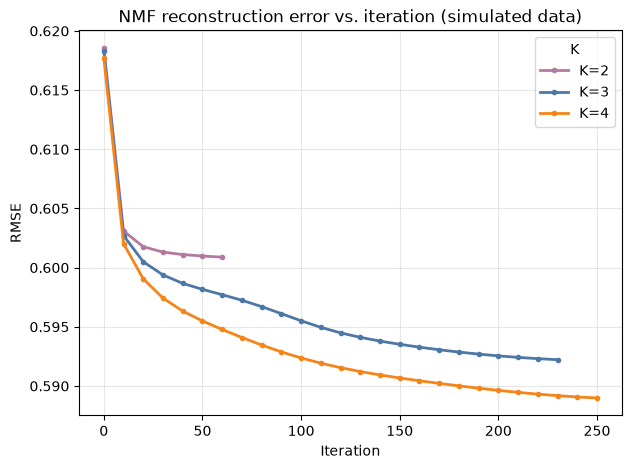

In [5]:
# Plotting RMSE vs. iteration for each K.
fig, ax = plt.subplots(figsize=(7, 5))
colors = {2: "#B279A2", 3: "#4C78A8", 4: "#F58518"}
for k, res in nmf_results_sim.items():
    iters = [h[0] for h in res["history"]]
    rmses = [h[1] for h in res["history"]]
    ax.plot(iters, rmses, marker="o", markersize=3, lw=2, label=f"K={k}", color=colors[k])
ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE")
ax.set_title("NMF reconstruction error vs. iteration (simulated data)")
ax.legend(title="K")
ax.grid(True, alpha=0.3)
plt.show()

### Build a `df_admixture`-shaped DataFrame

`ag3.admixture()` normally returns a tidy DataFrame with `sample_id`, `pop1` ... `popK` columns joined to sample metadata. We reproduce the same shape here from the simulated `Q` matrix (K=3) so that we can reuse the package's plotting methods unmodified.

In [6]:
# Inspect the inferred admixture proportions for K=3, which is the correct number of ancestral populations in this simulation.
Q_sim = nmf_results_sim[3]["Q"]
df_admixture_sim = pd.DataFrame(Q_sim, columns=["pop1", "pop2", "pop3"])
df_admixture_sim.insert(0, "sample_id", sample_id_sim)
df_admixture_sim["population"] = population_sim
df_admixture_sim.head()

,sample_id,pop1,pop2,pop3,population
0,SIM000,0.941649,0.049936,0.008415,gambiae
1,SIM001,0.938563,0.058347,0.003090,gambiae
2,SIM002,0.960557,0.021861,0.017582,gambiae
3,SIM003,0.993854,0.003829,0.002317,gambiae
4,SIM004,0.976706,0.010883,0.012411,gambiae


### Plot ancestry proportions (simulated data, K=3)

We reuse the `plot_admixture*` methods provided by `AnophelesAdmixtureAnalysis` directly on our simulated `df_admixture_sim`, since these methods only require a DataFrame with `sample_id` / `pop1..popK` columns plus metadata to colour or split by - they do not need to reload data from GCS.

In [7]:
ag3.plot_admixture(
    df_admixture_sim,
    k=3,
    sort_by="population",
    title="Admixture proportions (simulated data, K=3)",
    show=False,
)

In [8]:
ag3.plot_admixture_scatter(
    df_admixture_sim,
    k=3,
    x="pop1",
    y="pop2",
    color_by="population",
    title="Ancestry space scatter (simulated data, K=3)",
    show=False,
)

In [9]:
ag3.plot_admixture_ternary(
    df_admixture_sim,
    color_by="population",
    title="Ternary admixture plot (simulated data, K=3)",
    show=False,
)

In [10]:
# Plot ancestry proportion distributions by true population (simulated data)
ag3.plot_admixture_violin(
    df_admixture_sim,
    k=3,
    split_by="population",
    title="Ancestry proportion distributions by true population (simulated data)",
    show=False,
)

The scatter, ternary and violin plots all confirm that the three pure-ancestry populations form tight, well-separated clusters near the vertices/extremes of ancestry space, while the admixed cohort falls neatly between the `gambiae` and `coluzzii` clusters, as expected from the simulation design.

## Real data from MalariaGEN GCS

We now run the full `ag3.admixture()` pipeline on real *Anopheles gambiae* complex whole-genome sequencing data from the Ag3 data resource on Google Cloud Storage. Sample sets are chosen to span the three major species within the *An. gambiae* complex:

| Sample set | Country | Dominant species |
|---|---|---|
| AG1000G-GM-A | The Gambia | gambiae + coluzzii |
| AG1000G-AO | Angola | coluzzii |
| AG1000G-KE | Kenya | arabiensis |
| AG1000G-UG | Uganda | gambiae |
| AG1000G-BF-A | Burkina Faso | gambiae + coluzzii |

Results are cached to disk (`results_cache`) so that re-running this notebook is fast.

In [11]:
df_admix = ag3.admixture(
    region="3L:15,000,000-16,000,000",
    sample_sets=["AG1000G-GM-A", "AG1000G-AO", "AG1000G-KE", "AG1000G-UG", "AG1000G-BF-A"],
    k=3,
    n_snps=50_000,
    site_mask="gamb_colu_arab",
    random_seed=42,
)
df_admix.head()

,sample_id,pop1,pop2,pop3,partner_sample_id,contributor,country,location,year,month,...,admin1_name,admin1_iso,admin2_name,taxon,cohort_admin1_year,cohort_admin1_month,cohort_admin1_quarter,cohort_admin2_year,cohort_admin2_month,cohort_admin2_quarter
0,AR0047-C,0.276260,0.526994,0.196747,LUA047,Joao Pinto,Angola,Luanda-A,2009,4,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
1,AR0049-C,0.286776,0.522482,0.190742,LUA049,Joao Pinto,Angola,Luanda-A,2009,4,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
2,AR0051-C,0.299163,0.531595,0.169242,LUA051,Joao Pinto,Angola,Luanda-A,2009,4,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
3,AR0061-C,0.304542,0.514075,0.181382,LUA061,Joao Pinto,Angola,Luanda-A,2009,4,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
4,AR0078-C,0.240453,0.546568,0.212979,LUA078,Joao Pinto,Angola,Luanda-A,2009,4,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2


### Ancestry proportions — stacked bar (STRUCTURE-style)

In [12]:
ag3.plot_admixture(
    df_admix,
    k=3,
    sort_by="aim_species",
    title="Admixture proportions (Ag3 real data, K=3)",
    show=False,
)

### Ancestry space scatter

In [13]:
ag3.plot_admixture_scatter(
    df_admix,
    k=3,
    x="pop1",
    y="pop2",
    color_by="aim_species",
    title="Ancestry space scatter (Ag3 real data, K=3)",
    show=False,
)

### Ternary plot

In [14]:
ag3.plot_admixture_ternary(
    df_admix,
    color_by="aim_species",
    title="Ternary admixture plot (Ag3 real data, K=3)",
    show=False,
)

### Ancestry proportion distributions by country

In [15]:
ag3.plot_admixture_violin(
    df_admix,
    k=3,
    split_by="country",
    title="Ancestry proportion distributions by country (Ag3 real data, K=3)",
    show=False,
)

### Exploring a different K

Increasing K to 4 can reveal finer-scale population structure not captured by K=3 (e.g. splitting a taxon into sub-clusters). We recompute admixture with K=4 for the same cohort and compare the stacked-bar and violin plots.

In [16]:
df_admix_k4 = ag3.admixture(
    region="3L:15,000,000-16,000,000",
    sample_sets=["AG1000G-GM-A", "AG1000G-AO", "AG1000G-KE", "AG1000G-UG", "AG1000G-BF-A"],
    k=4,
    n_snps=50_000,
    site_mask="gamb_colu_arab",
    random_seed=42,
)
df_admix_k4.head()

,sample_id,pop1,pop2,pop3,pop4,partner_sample_id,contributor,country,location,year,...,admin1_name,admin1_iso,admin2_name,taxon,cohort_admin1_year,cohort_admin1_month,cohort_admin1_quarter,cohort_admin2_year,cohort_admin2_month,cohort_admin2_quarter
0,AR0047-C,0.373536,0.153936,0.269839,0.202689,LUA047,Joao Pinto,Angola,Luanda-A,2009,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
1,AR0049-C,0.462078,0.179075,0.183619,0.175229,LUA049,Joao Pinto,Angola,Luanda-A,2009,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
2,AR0051-C,0.347439,0.153726,0.286001,0.212834,LUA051,Joao Pinto,Angola,Luanda-A,2009,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
3,AR0061-C,0.377579,0.159954,0.247665,0.214803,LUA061,Joao Pinto,Angola,Luanda-A,2009,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
4,AR0078-C,0.401865,0.158701,0.265825,0.173609,LUA078,Joao Pinto,Angola,Luanda-A,2009,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2


In [17]:
ag3.plot_admixture(
    df_admix_k4,
    k=4,
    sort_by="aim_species",
    title="Admixture proportions (Ag3 real data, K=4)",
    show=False,
)

In [18]:
ag3.plot_admixture_violin(
    df_admix_k4,
    k=4,
    split_by="aim_species",
    title="Ancestry proportion distributions by species (Ag3 real data, K=4)",
    show=False,
)